In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import skspatial.objects as so
import sys
import os

In [2]:
import sys, os
sys.path.append(os.path.abspath("../turb_template"))
import units_cool as un
from units import pressure, mu, KELVIN, CONST_kB, CONST_amu, unit_q, unit_time, unit_density, unit_length

In [3]:
import importlib.util

def load_v_turb(path_to_input_py):
    spec = importlib.util.spec_from_file_location("input_module", path_to_input_py)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.v_turb

v_turb_01 = load_v_turb("/ptmp/mpa/ankitad/athenapk/nc_256_01/input.py")
v_turb_03 = load_v_turb("/ptmp/mpa/ankitad/athenapk/nc_256_03/input.py")
v_turb_05 = load_v_turb("/ptmp/mpa/ankitad/athenapk/nc_256_05/input.py")
v_turb_07 = load_v_turb("/ptmp/mpa/ankitad/athenapk/nc_256_075/input.py")
v_turb_09 = load_v_turb("/ptmp/mpa/ankitad/athenapk/nc_256_09/input.py")

# Reading and Loading

In [4]:
hst_file = [
    "/ptmp/mpa/ankitad/athenapk/nc_rst_256_01/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/nc_rst_256_03/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/nc_rst_256_05/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/nc_rst_256_075/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/nc_rst_256_09/parthenon.out1.hst"
]

files = ["/ptmp/mpa/ankitad/athenapk/nc_rst_256_01/parthenon.prim.00193.phdf", 
        "/ptmp/mpa/ankitad/athenapk/nc_rst_256_03/parthenon.prim.00193.phdf", 
        "/ptmp/mpa/ankitad/athenapk/nc_rst_256_05/parthenon.prim.00193.phdf", 
        "/ptmp/mpa/ankitad/athenapk/nc_rst_256_075/parthenon.prim.00193.phdf", 
        "/ptmp/mpa/ankitad/athenapk/nc_rst_256_09/parthenon.prim.00193.phdf"
        ]

In [5]:
def read_hdf5(filename):
    with h5py.File(filename, "r") as f:
        print(f"Keys: {f.keys()} \n")
        print(f"Attributes: {f.attrs.keys()} \n")

        prim = f["prim"][()]
        rho = prim[:, 0]
        prs = prim[:, 4]  
        
        # vel1 = prim[1]
        # vel2 = prim[2]
        # vel3 = prim[3]

        # x1 = f["x1v"][()]
        # x2 = f["x2v"][()]
        # x3 = f["x3v"][()]

        LogicalLocations = f["LogicalLocations"][()]
        MeshBlockSize = np.array(rho.shape[1:4])     # auto-detect 
        NumMeshBlocks = rho.shape[0]
        RootGridSize = np.array([256, 256, 256])
    
        print("np.shape(LogicalLocations) =", np.shape(LogicalLocations))
        print("np.shape(rho) =", np.shape(rho))
        print("RootGridSize =", RootGridSize)
        print("NumMeshBlocks =", NumMeshBlocks)
        print("LogicalLocations[10] =", LogicalLocations[5])

        # print(f"{np.shape(x1) = }")
        # print(f"{np.shape(x2) = }")
        # print(f"{np.shape(x3) = }\n")
        
    #print(f"{LogicalLocations[10] = }")

    rho_full = np.zeros(tuple(RootGridSize), dtype=float)
    prs_full = np.zeros(tuple(RootGridSize), dtype=float)

    # x1_full = np.zeros(np.product(np.shape(x1)), dtype=float)
    # x2_full = np.zeros(np.product(np.shape(x2)), dtype=float)
    # x3_full = np.zeros(np.product(np.shape(x3)), dtype=float)

    for i in range(NumMeshBlocks):
        start1 = MeshBlockSize[0] * LogicalLocations[i][0]
        end1 = start1 + MeshBlockSize[0]

        start2 = MeshBlockSize[1] * LogicalLocations[i][1]
        end2 = start2 + MeshBlockSize[1]

        start3 = MeshBlockSize[2] * LogicalLocations[i][2]
        end3 = start3 + MeshBlockSize[2]

        rho_full[start3:end3, start2:end2, start1:end1] = rho[i]

        prs_full[start3:end3, start2:end2, start1:end1] = prs[i]

    #     x1_full[start1:end1] = x1[i]
    #     x2_full[start2:end2] = x2[i]
    #     x3_full[start3:end3] = x3[i]

    # T = prs_full / rho_full

    return rho_full, prs_full

In [6]:
def read_hst_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_line = next(line for line in lines if line.startswith("# [1]"))
    headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]
    data = np.loadtxt(filename)
    return headers, data

def read_hst_rst(filename):
    headers = [
        "time", "dt", "cycle", "nbtotal", "mass",
        "1-mom", "2-mom", "3-mom", "KE", "tot-E",
        "Ms", "DeltaEcool"
    ]
    
    data = np.loadtxt(filename)
    return headers, data


In [7]:
# Call the data loader
rho_full_01, prs_full_01 = read_hdf5(files[0])
rho_full_03, prs_full_03 = read_hdf5(files[1])
rho_full_05, prs_full_05 = read_hdf5(files[2])
rho_full_07, prs_full_07 = read_hdf5(files[3])
rho_full_09, prs_full_09 = read_hdf5(files[4])

Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 64, 64, 64)
RootGridSize = [256 256 256]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 64, 64, 64)
RootGridSize = [256 256 256]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 64, 64, 64)
RootGridSize = [256 256 256]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <Key

In [8]:
headers_01, data_01 = read_hst_rst(hst_file[0])
headers_03, data_03 = read_hst_rst(hst_file[1])
headers_05, data_05 = read_hst_rst(hst_file[2])
headers_075, data_075 = read_hst_rst(hst_file[3])
headers_09, data_09 = read_hst_rst(hst_file[4])

# Index map
time_idx_01 = headers_01.index("time")
mass_idx_01 = headers_01.index("mass")
ke_idx_01   = headers_01.index("KE")
etot_idx_01= headers_01.index("tot-E")

time_idx_03 = headers_03.index("time")
mass_idx_03 = headers_03.index("mass")
ke_idx_03   = headers_03.index("KE")
etot_idx_03= headers_03.index("tot-E")

time_idx_05 = headers_05.index("time")
mass_idx_05 = headers_05.index("mass")
ke_idx_05   = headers_05.index("KE")
etot_idx_05 = headers_05.index("tot-E")

time_idx_075 = headers_075.index("time")
mass_idx_075 = headers_075.index("mass")
ke_idx_075   = headers_075.index("KE")
etot_idx_075= headers_075.index("tot-E")

time_idx_09 = headers_09.index("time")
mass_idx_09 = headers_09.index("mass")
ke_idx_09   = headers_09.index("KE")
etot_idx_09 = headers_09.index("tot-E")

# Extract data
time_01 = data_01[:, time_idx_01]
mass_01 = data_01[:, mass_idx_01]
KE_01   = data_01[:, ke_idx_01]
Etot_01 = data_01[:, etot_idx_01]

time_03 = data_03[:, time_idx_03]
mass_03 = data_03[:, mass_idx_03]
KE_03   = data_03[:, ke_idx_03]
Etot_03 = data_03[:, etot_idx_03]

time_05 = data_05[:, time_idx_05]
mass_05 = data_05[:, mass_idx_05]
KE_05   = data_05[:, ke_idx_05]
Etot_05 = data_05[:, etot_idx_05]

time_075 = data_075[:, time_idx_075]
mass_075 = data_075[:, mass_idx_075]
KE_075   = data_075[:, ke_idx_075]
Etot_075 = data_075[:, etot_idx_075]

time_09 = data_09[:, time_idx_09]
mass_09 = data_09[:, mass_idx_09]
KE_09   = data_09[:, ke_idx_09]
Etot_09 = data_09[:, etot_idx_09]

# Slices

In [9]:

# Visualize a midplane slice
def show_midplane_slice(data, label):

    plt.imshow(data[:, :, data.shape[2] // 2], origin='lower')
    plt.title(label)
    
    plt.colorbar(label=label)
    plt.show()

In [10]:
def show_midplane_panel(data_list, labels, vmin=None, vmax=None, ncols=3, log_scale=True, slice_index=20, field_name="Quantity"):
    """
    Show midplane slices of log10(density) in a multi-row grid.

    Parameters:
    - density_list: list of 3D arrays
    - mach_labels: list of strings for subplot titles
    - vmin, vmax: optional color limits
    - ncols: number of columns in the grid (default = 3)
    """
    n = len(data_list)
    nrows = (n + ncols - 1) // ncols  # auto-calculate rows needed

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)  # flatten in case of 2D axes array

    for i in range(len(axes)):
        ax = axes[i]
        if i < n:
            rho = data_list[i]
            label = labels[i]
            rho_safe = np.where(rho <= 0, 1e-20, rho)
            log_rho = np.log10(rho_safe)
            #mid = log_rho.shape[2] // 2
            #im = ax.imshow(log_rho[:, :, mid], origin='lower', vmin=vmin, vmax=vmax)
            slice_index = 20
            im = ax.imshow(log_rho[:, :, slice_index], origin='lower', vmin=vmin, vmax=vmax)

            ax.set_title(f"{label} : log₁₀({field_name})")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.axis('off')  # empty subplot

    plt.show()


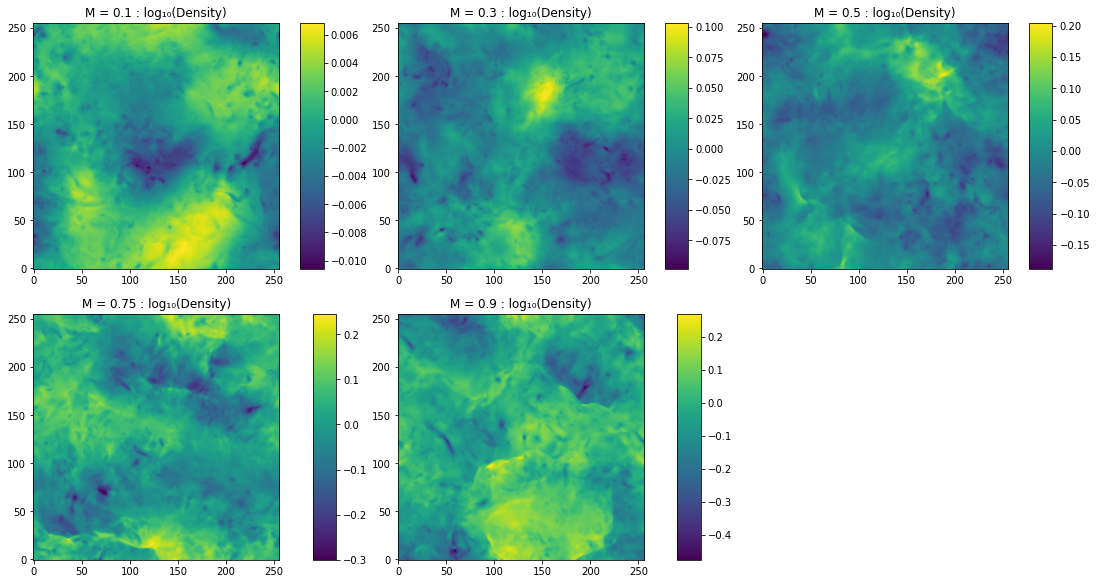

In [11]:
density_list = [rho_full_01, rho_full_03, rho_full_05, rho_full_07, rho_full_09]
mach_labels = ['M = 0.1', 'M = 0.3', 'M = 0.5', 'M = 0.75', 'M = 0.9']

# Optional: set consistent color scale
show_midplane_panel(density_list, mach_labels, field_name= "Density")


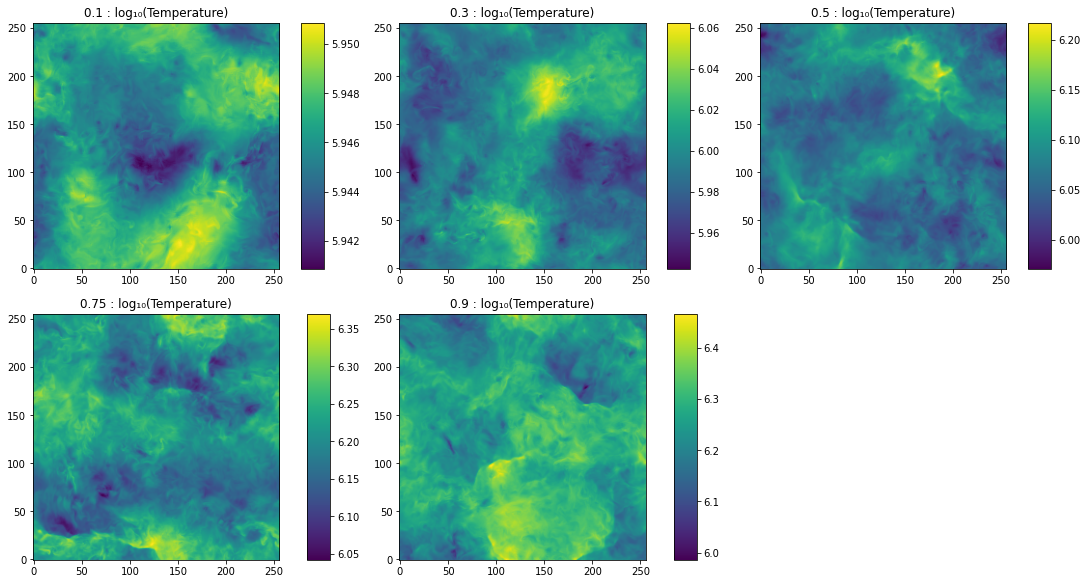

In [12]:
temp1 = [un.temperature(rho_full_01, prs_full_01), un.temperature(rho_full_03, prs_full_03), un.temperature(rho_full_05, prs_full_05), un.temperature(rho_full_07, prs_full_07), un.temperature(rho_full_09, prs_full_09)]
mach = [0.1, 0.3, 0.5, 0.75, 0.9]
show_midplane_panel(temp1, mach, field_name='Temperature')

# Distribution

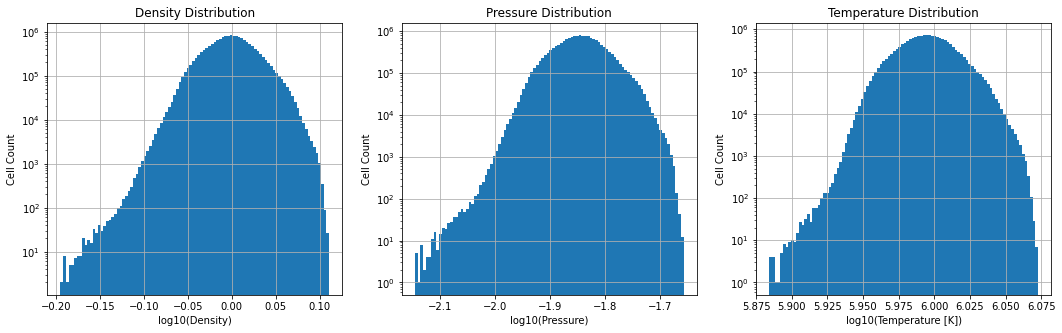

In [13]:
rho_flat = rho_full_03.flatten()
prs_flat = prs_full_03.flatten()

# Avoid division by zero
rho_safe = np.where(rho_flat == 0, 1e-20, rho_flat)
T_flat = (prs_flat / rho_safe) * (KELVIN * mu)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].hist(np.log10(rho_safe), bins=100, log=True)
axs[0].set_xlabel("log10(Density)")
axs[0].set_ylabel("Cell Count")
axs[0].set_title("Density Distribution")
axs[0].grid(True)

prs_safe = np.where(prs_flat <= 0, 1e-20, prs_flat)
axs[1].hist(np.log10(prs_safe), bins=100, log=True)
axs[1].set_xlabel("log10(Pressure)")
axs[1].set_ylabel("Cell Count")
axs[1].set_title("Pressure Distribution")
axs[1].grid(True)


T_safe = np.where(T_flat <= 0, 1e-20, T_flat)
axs[2].hist(np.log10(T_safe), bins=100, log=True)
axs[2].set_xlabel("log10(Temperature [K])")
axs[2].set_ylabel("Cell Count")
axs[2].set_title("Temperature Distribution")
axs[2].grid(True)

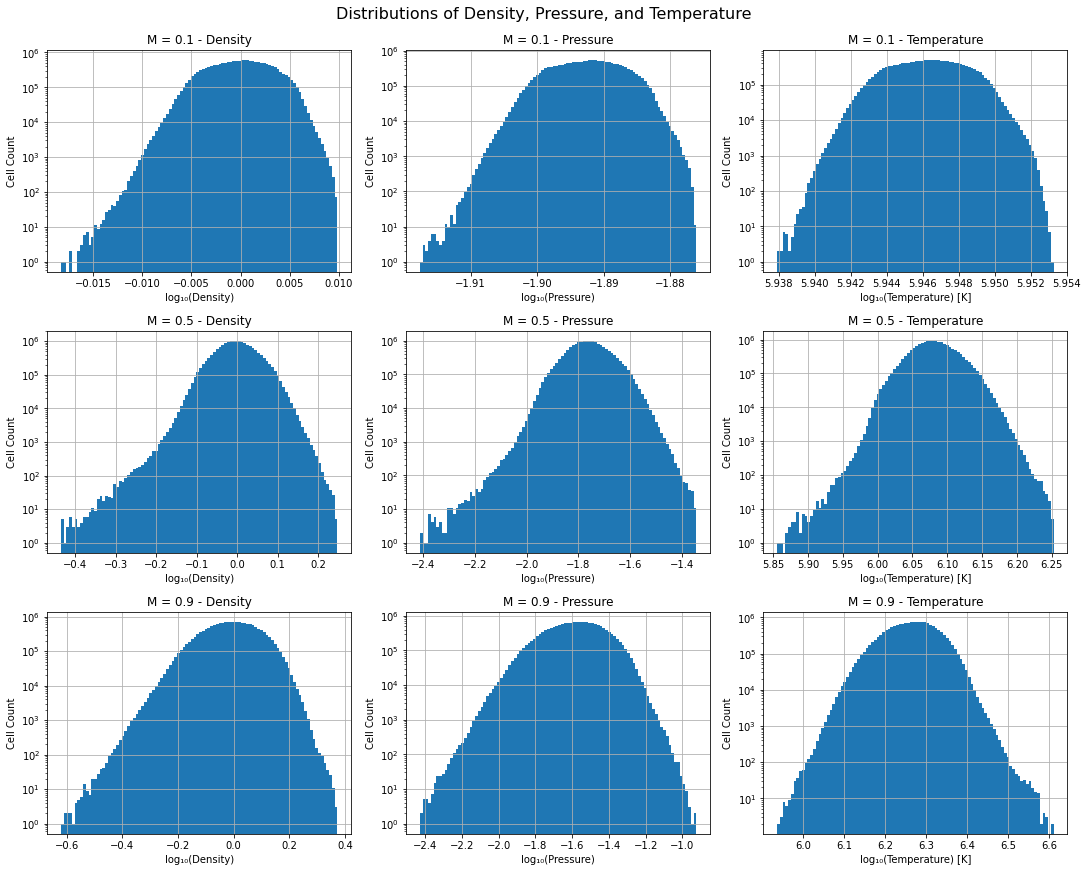

In [29]:
datasets = [
    #(rho_full_03, prs_full_03),
    (rho_full_01, prs_full_01),
    (rho_full_05, prs_full_05),
    (rho_full_09, prs_full_09)
]
labels = ["M = 0.1", "M = 0.5", "M = 0.9"]  # Update as appropriate

fig, axs = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

for i, (rho_full, prs_full) in enumerate(datasets):
    rho_flat = rho_full.flatten()
    prs_flat = prs_full.flatten()

    rho_safe = np.where(rho_flat <= 0, 1e-20, rho_flat)
    prs_safe = np.where(prs_flat <= 0, 1e-20, prs_flat)
    T_flat = (prs_safe / rho_safe) * (KELVIN * mu)
    T_safe = np.where(T_flat <= 0, 1e-20, T_flat)

    axs[i, 0].hist(np.log10(rho_safe), bins=100, log=True)
    axs[i, 0].set_xlabel("log₁₀(Density)")
    axs[i, 0].set_ylabel("Cell Count")
    axs[i, 0].set_title(f"{labels[i]} - Density")
    axs[i, 0].grid(True)

    axs[i, 1].hist(np.log10(prs_safe), bins=100, log=True)
    axs[i, 1].set_xlabel("log₁₀(Pressure)")
    axs[i, 1].set_ylabel("Cell Count")
    axs[i, 1].set_title(f"{labels[i]} - Pressure")
    axs[i, 1].grid(True)

    axs[i, 2].hist(np.log10(T_safe), bins=100, log=True)
    axs[i, 2].set_xlabel("log₁₀(Temperature) [K]")
    axs[i, 2].set_ylabel("Cell Count")
    axs[i, 2].set_title(f"{labels[i]} - Temperature")
    axs[i, 2].grid(True)

plt.suptitle("Distributions of Density, Pressure, and Temperature", fontsize=16)
plt.show()


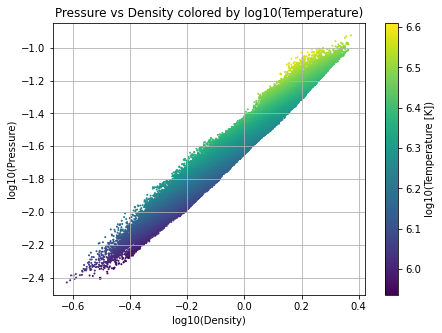

In [15]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(np.log10(rho_safe), np.log10(prs_safe), c=np.log10(T_safe), s=1, cmap='viridis')
plt.xlabel("log10(Density)")
plt.ylabel("log10(Pressure)")
plt.title("Pressure vs Density colored by log10(Temperature)")
plt.colorbar(sc, label="log10(Temperature [K])")
plt.grid(True)
plt.show()

Fitted gamma (slope): 1.5950
Intercept: -1.5691
R²: 0.97743


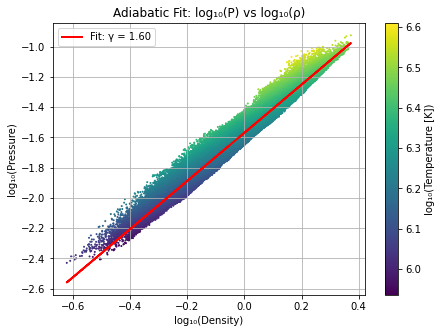

In [35]:
from scipy.stats import linregress

# Clean your data (remove non-physical values)
mask = (rho_safe > 0) & (prs_safe > 0)
log_rho = np.log10(rho_safe[mask])
log_prs = np.log10(prs_safe[mask])

# Linear fit: log(P) = γ log(ρ) + const
slope, intercept, r_value, p_value, stderr = linregress(log_rho, log_prs)

print(f"Fitted gamma (slope): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²: {r_value**2:.5f}")

plt.figure(figsize=(7, 5))
sc = plt.scatter(log_rho, log_prs, c=np.log10(T_safe[mask]), s=1, cmap='viridis')
plt.plot(log_rho, slope * log_rho + intercept, color='red', linewidth=2, label=f'Fit: γ = {slope:.2f}')
plt.xlabel("log₁₀(Density)")
plt.ylabel("log₁₀(Pressure)")
plt.title("Adiabatic Fit: log₁₀(P) vs log₁₀(ρ)")
plt.colorbar(sc, label="log₁₀(Temperature [K])")
plt.legend()
plt.grid(True)
plt.show()


# Turbulent Velocity Comparison

In [16]:
print(v_turb_01)
print(v_turb_03)
print(v_turb_05)
print(v_turb_07)
print(v_turb_09)


0.01554316959978925
0.046629508799367746
0.07771584799894625
0.11657377199841937
0.13988852639810326


In [17]:
v_turb_calc = np.sqrt(2* KE_05/mass_05)
t_eddy = 0.5/np.average(v_turb_calc[- 500 : ])
print("calculated v_turb = ", np.average(v_turb_calc[- 500 : ]))
print("v_turb from input file = ", v_turb_05)
print("Calculated t_eddy = ", t_eddy)

calculated v_turb =  0.08122893585626924
v_turb from input file =  0.07771584799894625
Calculated t_eddy =  6.155441958327835


In [18]:
t_per_eddy = time_05/t_eddy

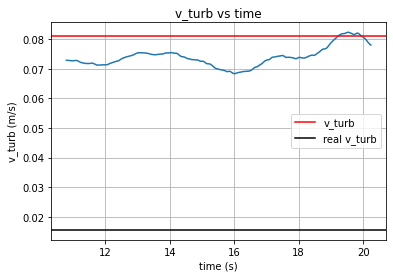

In [19]:
plt.plot(t_per_eddy, v_turb_calc)
plt.xlabel('time (s)')
plt.ylabel('v_turb (m/s)')
plt.axhline(np.average(v_turb_calc[- 500 : ]), color='r', label='v_turb')
plt.axhline(v_turb_01, color='k', label='real v_turb')
plt.title('v_turb vs time')
plt.legend()
plt.grid(which='both', axis='both')
plt.show()

In [20]:
print("Avg v_turb (last 500):", np.average(v_turb_calc[-500:]))
print("Mean of entire series:", np.mean(v_turb_calc))
print("Final value:", v_turb_calc[-1])

Avg v_turb (last 500): 0.08122893585626924
Mean of entire series: 0.07401842518496829
Final value: 0.07804127113265134


# Evolution of Temperature
The variables are : time_0* , mass_0* , KE_0* , Etot_0*  

In [21]:
# Compute internal energy
Etherm = Etot_05 - KE_05
#avg_T = (Etherm / mass) * (2 / 3) * ((mu*CONST_amu)/CONST_kB) * (unit_q * unit_time) * ((unit_density/ (unit_length)**3)**(-1)) # simple proportionality; constants absorbed
avg_T = (Etherm / mass_05) * (KELVIN) * (2/3)
v_turb_calc = np.sqrt(2* KE_05/mass_05)
t_eddy = 0.5/np.average(v_turb_calc[- 500 : ])
t_per_eddy = time_05/t_eddy

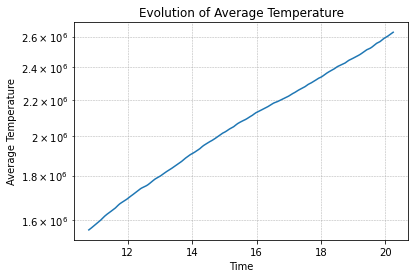

In [22]:
plt.plot(t_per_eddy, avg_T)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Average Temperature")
plt.title("Evolution of Average Temperature")
plt.grid(which='both', axis='both', linestyle='--', linewidth=0.5)
plt.show()

In [23]:
Etherm = Etot_05 - KE_05
epsilon = Etherm / mass_05
time = time_05
dedt = np.gradient(epsilon, time)
avg_dedt = np.mean(dedt[-500:])
print(f"Estimated global heating rate: {-avg_dedt:.5e}")
print(-0.5*(v_turb_05**3)*np.average(mass_01))

Estimated global heating rate: -3.09868e-04
-0.00023469226422291717


In [24]:
import numpy as np

# Your existing arrays
Etherm = Etot_01 - KE_01
epsilon = Etherm / mass_01
time = time_01

# Define rescaling time from input file
t_rescale = 6*t_eddy

# Mask only post-rescaling data
mask = time > t_rescale

# Apply mask
epsilon_post = epsilon[mask]
time_post = time[mask]

# Compute dε/dt only after rescaling
dedt_post = np.gradient(epsilon_post, time_post)
avg_dedt = np.mean(dedt_post[-500:])  # or fewer depending on length

print(f"Estimated global heating rate: {-avg_dedt:.5e}")


Estimated global heating rate: -2.12164e-06


# Tracers

In [25]:
from pathlib import Path
import sys

sys.path.insert(
    1,
    "../external/parthenon" + "/scripts/python/packages/parthenon_tools/parthenon_tools",
)

try:
    import phdf
except ModuleNotFoundError:
    print("Couldn't find module to read Parthenon hdf5 files.")


In [48]:
filenames = [f"/ptmp/mpa/ankitad/athenapk/nc_rst_256_09/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)] 

rho_list = []

for i, filename in enumerate(filenames):
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    xs = tracers.x
    ys = tracers.y
    zs = tracers.z
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    rho_list.append(rho)


In [49]:

# Concatenate all frames' tracer density
all_rho = np.concatenate(rho_list)

print("Tracer density stats:")
print(f"Mean: {np.mean(all_rho):.3e}")
print(f"Std : {np.std(all_rho):.3e}")
print(f"Min : {np.min(all_rho):.3e}")
print(f"Max : {np.max(all_rho):.3e}")


Tracer density stats:
Mean: 1.061e+00
Std : 2.440e-01
Min : 1.271e-01
Max : 3.200e+00


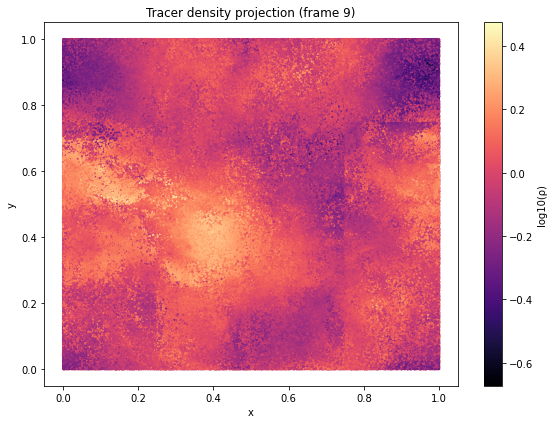

In [ ]:

# Just take a single frame for now (e.g., frame 0)
frame = 9
data = phdf.phdf(filenames[frame])
tracers = data.GetSwarm("tracers")

x = tracers.x
y = tracers.y
rho = tracers.Get("rho")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=np.log10(rho), s=1, cmap='magma')
plt.colorbar(label='log10(ρ)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Tracer density projection (frame {frame})')
plt.tight_layout()
plt.show()


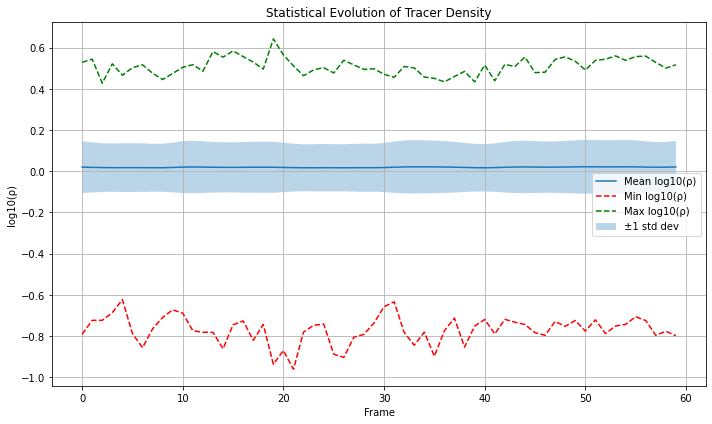

In [ ]:
means = []
mins = []
maxs = []
stds = []

for rho in rho_list:
    log_rho = np.log10(rho)
    means.append(np.mean(log_rho))
    mins.append(np.min(log_rho))
    maxs.append(np.max(log_rho))
    stds.append(np.std(log_rho))

frames = np.arange(len(rho_list))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(frames, means, label='Mean log10(ρ)')
plt.fill_between(frames, np.array(means)-np.array(stds), np.array(means)+np.array(stds),
                 alpha=0.3, label='±1 std dev')
plt.plot(frames, mins, '--', label='Min log10(ρ)', color='red')
plt.plot(frames, maxs, '--', label='Max log10(ρ)', color='green')

plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Statistical Evolution of Tracer Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Selected tracer IDs: [40513]


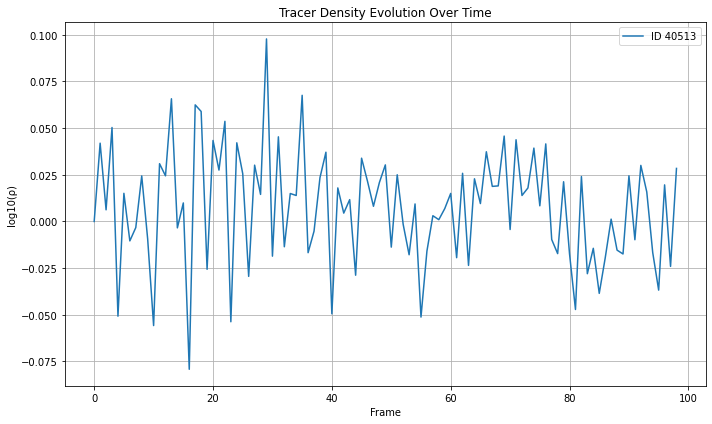

In [ ]:
data0 = phdf.phdf(filenames[0])
tracers0 = data0.GetSwarm("tracers")
ids0 = tracers0.Get("id")

import numpy as np
selected_ids = np.random.choice(ids0, size=1, replace=False)
print("Selected tracer IDs:", selected_ids)

# Initialize storage
id_rho_dict = {tid: [] for tid in selected_ids}

for filename in filenames:
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    for tid in selected_ids:
        match = np.where(ids == tid)[0]
        if len(match) == 1:
            id_rho_dict[tid].append(np.log10(rho[match[0]]))  # log scale
        else:
            id_rho_dict[tid].append(np.nan)


plt.figure(figsize=(10, 6))
for tid, log_rhos in id_rho_dict.items():
    plt.plot(log_rhos, label=f'ID {tid}')
plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Tracer Density Evolution Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

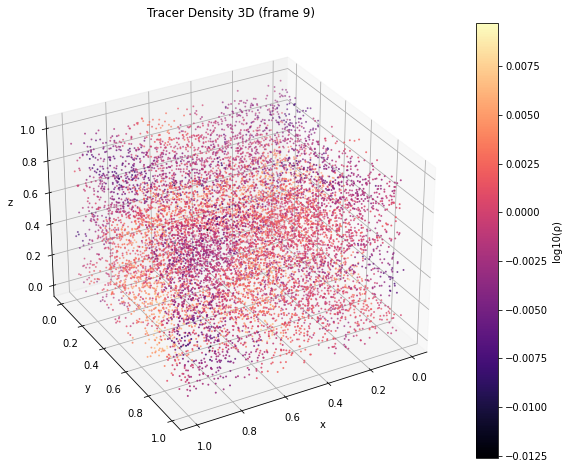

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter

frame = 9
data = phdf.phdf(filenames[frame])
tracers = data.GetSwarm("tracers")

x_all = tracers.x
y_all = tracers.y
z_all = tracers.z
rho_all = tracers.Get("rho")

n_total = len(x_all)
n_sample = 10000  # number of particles to plot
idx = np.random.choice(n_total, min(n_sample, n_total), replace=False)

x = x_all[idx]
y = y_all[idx]
z = z_all[idx]
rho = rho_all[idx]

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=np.log10(rho), s=1, cmap='magma')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f'Tracer Density 3D (frame {frame})')
fig.colorbar(sc, ax=ax, label='log10(ρ)')

# Rotation function
def update(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Animate
n_frames = 90  # more frames = smoother
anim = FuncAnimation(fig, update, frames=np.linspace(0, 360, n_frames), blit=False)

anim.save("tracer_rotation.gif", writer=PillowWriter(fps=15))

plt.close()


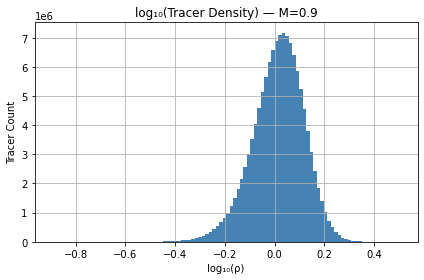

In [50]:
rho_list = []

for filename in filenames:
    try:
        data = phdf.phdf(filename)
        tracers = data.GetSwarm("tracers")
        rho = tracers.Get("rho")
        rho_list.append(rho)
    except Exception as e:
        print(f"Skipped {filename}: {e}")

# Combine all tracer densities
all_rho = np.concatenate(rho_list)
all_rho_safe = np.where(all_rho <= 0, 1e-20, all_rho)
log_all_rho = np.log10(all_rho_safe)

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(log_all_rho, bins=100, color='steelblue')
plt.title("log₁₀(Tracer Density) — M=0.9")
plt.xlabel("log₁₀(ρ)")
plt.ylabel("Tracer Count")
plt.grid(True)
plt.tight_layout()
plt.show()